In [1]:
import os
import glob

import numpy as np
import pandas as pd

from tator_tools.download_query import QueryDownloader
from tator_tools.yolo_dataset import YOLODataset
from tator_tools.download_rf_dataset import RoboflowDatasetDownloader

# Download Query from Tator

In [2]:
# Set parameters
api_token = os.getenv("TATOR_TOKEN")
project_id = 70  # 155

# Search string comes from Tator's Data Metadata Export utility
search_string = "eyJtZXRob2QiOiJBTkQiLCJvcGVyYXRpb25zIjpbeyJtZXRob2QiOiJPUiIsIm9wZXJhdGlvbnMiOlt7ImF0dHJpYnV0ZSI6IiR0eXBlIiwib3BlcmF0aW9uIjoiZXEiLCJpbnZlcnNlIjpmYWxzZSwidmFsdWUiOjUwMH1dfV19"

# Demo for downloading labeled data
frac = 1.0

dataset_name = "DebrisFinder"
output_dir = "../Data"

label_field = "MarineDebris"

In [3]:
# Create a downloader for the labeled data
downloader = QueryDownloader(api_token,
                             project_id=project_id,
                             search_string=search_string,
                             frac=frac,
                             output_dir=output_dir,
                             dataset_name=dataset_name,
                             label_field=label_field)

NOTE: Authentication successful for jordan.pierce
NOTE: Search string saved to e:\tator-tools\Data\DebrisFinder\search_string.txt


In [4]:
# Download the labeled data
downloader.download_data()

NOTE: Querying Tator for labeled data
NOTE: Found 942 objects in query


Processing query: 100%|██████████| 942/942 [00:00<00:00, 27705.95it/s]


NOTE: Found 942 query objects after sampling
NOTE: Data saved to e:\tator-tools\Data\DebrisFinder\data.csv
NOTE: Data saved to e:\tator-tools\Data\DebrisFinder\data.json
NOTE: Downloading images to e:\tator-tools\Data\DebrisFinder\images


NOTE: Images downloaded to e:\tator-tools\Data\DebrisFinder\images


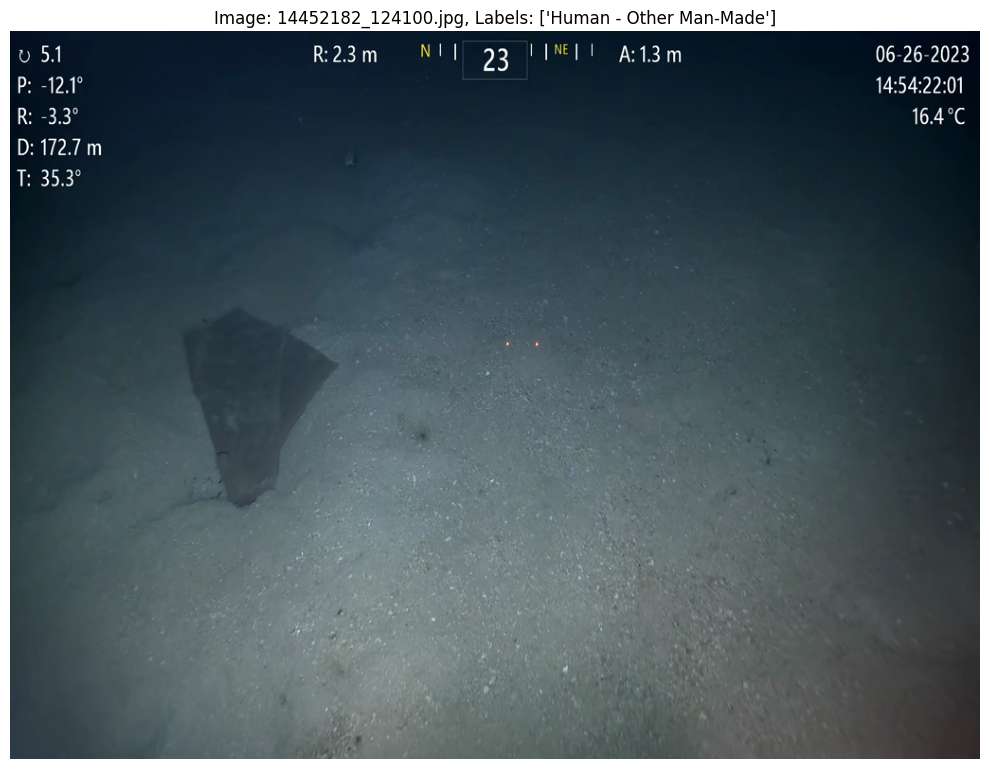

In [5]:
downloader.display_sample()

In [6]:
df = downloader.as_dataframe()  # .as_dict()

# Do some data exploration, filtering as needed
# Example: Drop all rows where x, y, width, or height is NaN
# df = df.dropna(subset=["x", "y", "width", "height"])
print(df.shape)

df.sample(3)

(942, 12)


,media,frame,image_name,image_path,image_width,image_height,x,y,width,height,polygon,label
694,14392964,174336,14392964_174336.jpg,e:\tator-tools\Data\DebrisFinder\images\143929...,None,None,0.097038,0.287794,0.606607,0.481650,[],
709,15434933,0,15434933_0.jpg,e:\tator-tools\Data\DebrisFinder\images\154349...,None,None,NaN,NaN,NaN,NaN,[],Research - (Other) Lander
698,14392964,187864,14392964_187864.jpg,e:\tator-tools\Data\DebrisFinder\images\143929...,None,None,0.403909,0.483591,0.596091,0.396039,[],


In [7]:
# Rename all of the classes
df["label"] = 'trash'

# Convert Data into YOLO-formatted Dataset

In [8]:
# Set parameters
output_dir = f"{output_dir}/{dataset_name}"
yolo_name = "YOLO_Dataset_MDBC_Relabeled_Trash"

train_ratio = 0.8
test_ratio = 0.1

task = 'detect' # 'detect' or 'segment'

In [10]:
# Create and process dataset
dataset = YOLODataset(
    data=df,
    output_dir=output_dir,
    dataset_name=yolo_name,
    train_ratio=train_ratio,
    test_ratio=test_ratio,
    task=task,
    format_class_names=True, 
)

In [ ]:
# Process the dataset
dataset.process_dataset(move_images=False)  # Makes a copy of the images instead of moving them

In [11]:
dataset.dataset_dir

'e:\\tator-tools\\Data\\DebrisFinder\\YOLO_Dataset_MDBC_Relabeled_Trash'

### Download RF Datasets

In [12]:
downloader = RoboflowDatasetDownloader(api_key=os.getenv("ROBOFLOW_API_KEY"))

In [24]:
urls = [
    "https://universe.roboflow.com/debris/deep-sea-debris-detection-dataset/dataset/1",
    "https://universe.roboflow.com/plastic-c1ye3/bharath/dataset/1",
    "https://universe.roboflow.com/underwater-ztbtg/thesis-rkzov/dataset/9",
    "https://universe.roboflow.com/object-detection-vtdep/trashcan_val/dataset/1"
]

In [37]:
output_dir = "../Data/DebrisFinder/Roboflow_Raw"

# Choose download method based on input type
dataset = downloader.download_from_url(
    url=urls[3],
    output_dir=output_dir,
)

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 85.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to ../Data/DebrisFinder/Roboflow_Raw/trashcan_val in yolov8:: 100%|██████████| 9176/9176 [00:27<00:00, 327.95it/s]

Dataset downloaded to: e:\tator-tools\Data\DebrisFinder\Roboflow_Raw\trashcan_val


In [38]:
ds = downloader.get_supervision_dataset()

Loaded train dataset with 3207 samples
Loaded valid dataset with 917 samples
Loaded test dataset with 458 samples
Merged dataset contains 4582 samples


In [53]:
# Map all classes to "trash"
classes = ["trash" if "trash" in label.lower() else "drop" for label in ds.classes]
selected_classes = [v for v in range(len(classes)) if classes[v] == "trash"]
print(f"Original classes: {ds.classes}")
print(f"Mapped classes: {classes}")
selected_classes

Original classes: ['01_Clam', '03_Crab', '05_Eel', '06_Fish', '19_Starfish', '22_Plastic', '24_ROV', '25_Rock', '26_Trash', '28_Reef', '35_Trash', '36_Trash', '37_Trash', '38_Trash', '39_Trash', '40_Trash', '41_Trash', '42_Trash', '43_Trash', '44_Trash', '45_Trash', '46_trash']
Mapped classes: ['drop', 'drop', 'drop', 'drop', 'drop', 'drop', 'drop', 'drop', 'trash', 'drop', 'trash', 'trash', 'trash', 'trash', 'trash', 'trash', 'trash', 'trash', 'trash', 'trash', 'trash', 'trash']


[8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]

In [54]:
for image_name, detections in ds.annotations.items():
    detections = detections[np.isin(detections.class_id, selected_classes)]

In [55]:
ds.classes = ['trash']

In [56]:
data_output_dir = f"../Data/DebrisFinder/YOLO_Dataset_{downloader.dataset.name.replace(' ', '_')}"

downloader.export_to_yolo(ds, output_dir=data_output_dir)

Exporting dataset with 3207 train, 916 validation, and 459 test samples
Dataset exported to ../Data/DebrisFinder/YOLO_Dataset_TrashCan_val


'../Data/DebrisFinder/YOLO_Dataset_TrashCan_val'